<a href="https://colab.research.google.com/github/musabegumm/DSC110/blob/main/Model_Evaluation_%26_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Model Evaluation: Evaluation of Classification models**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
#Here we're reading 4 files (ex. x_train, features, variables, inputs, or predictors that will be used to build the model)
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#to prevent warning, converting the y from df to 1d series
y_train = y_train.squeeze()
# y_test is used to test if the result is good or bad.
y_test  = y_test.squeeze()

# y_train & y_test are just one feature/one field --> so it's imported usually as one dimensional series

In [5]:
# Here we're starting to build the model.
# The 1st line here is creating an object for the model. The object is the "RandomForestClassifier"
rf = RandomForestClassifier(random_state=42)
# The 2nd line down below, is the object we build ".fit" means fitting the model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Meachine Learning is detecting patterns between the input data and the outpt data (ex. Logistic Regression, Random Forest)

In [6]:
from sklearn.metrics import classification_report, roc_auc_score
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
#print(classification_report(y_test, y_pred, labels=[1]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1289
           1       0.29      0.06      0.11       216

    accuracy                           0.84      1505
   macro avg       0.58      0.52      0.51      1505
weighted avg       0.78      0.84      0.80      1505

AUC-ROC: 0.7488


In [9]:
#Above, .predict returns the hard class labels while predict_proba returns probabilities for each class
#classification_report prints out the table of perclass metrics.
#y_pred to predict the yes or no and or 0 or 1

In [7]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [8]:
y_prob

array([0.11, 0.  , 0.  , ..., 0.08, 0.42, 0.08])

# **Explainability**

## **SHAP**: Shapley Additive Explanations

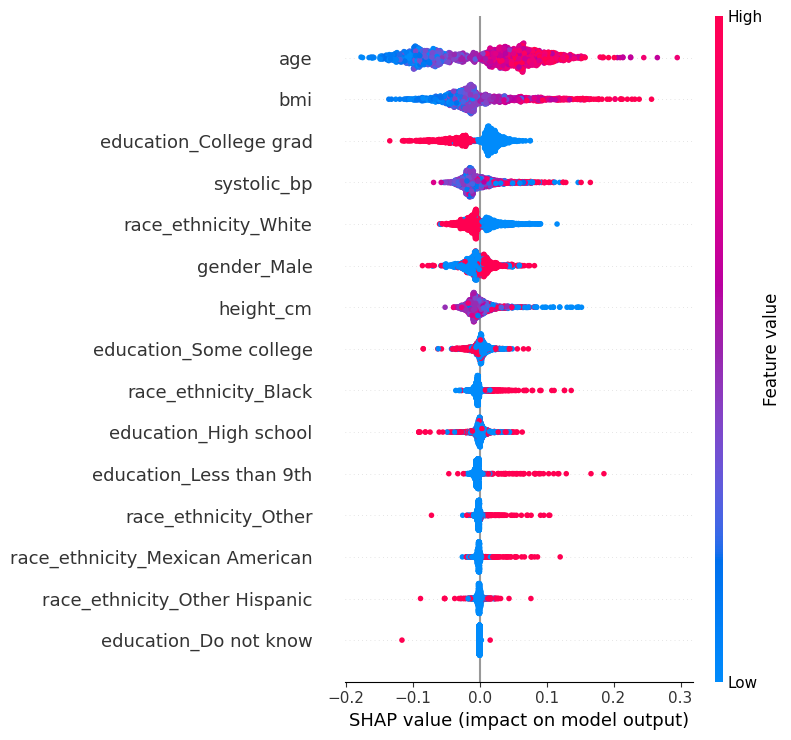

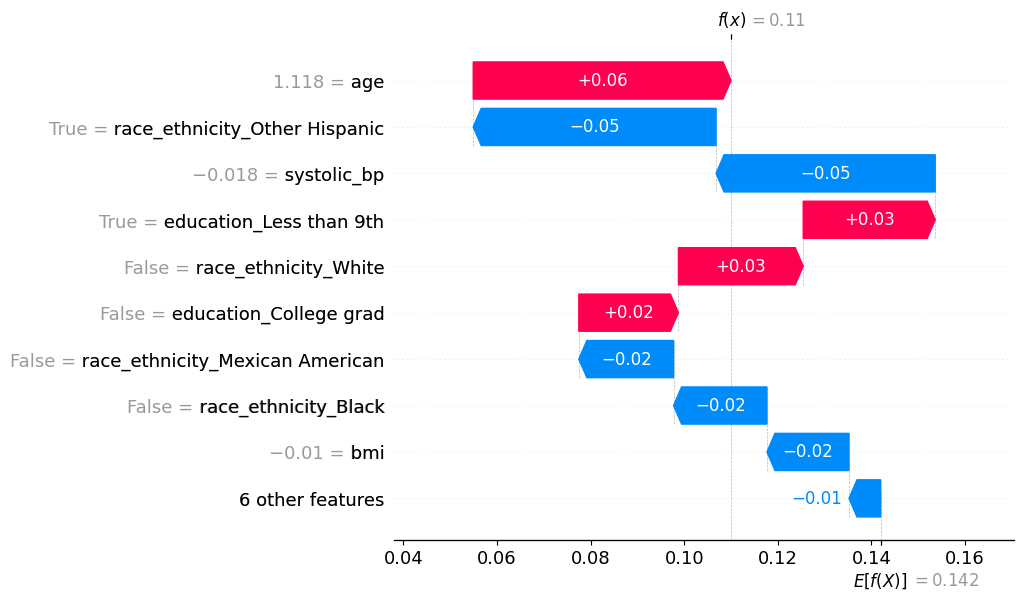

In [15]:
#SHAP: explains predictions at the individual predictions at the individual ovservation level. Morever, SHAP removes each feature one at a time & measures how much the prediction changes.
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)          # newer API — returns Explanation object

# overall summary plot
shap.summary_plot(shap_values[:, :, 1], X_test)   # [:, :, 1] = all rows, all features, positive class

# single observation (row 0)
shap.plots.waterfall(shap_values[0, :, 1])         # cleaner than force_plot for single obs

## **PDT**: Partial Dependence Plot

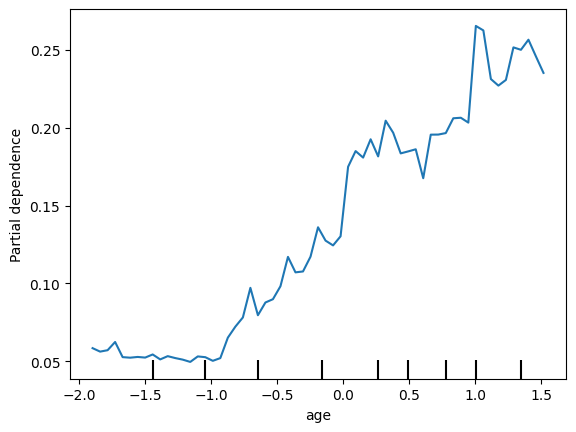

In [16]:
#This visualize how individual features relate to predicted outcomes. It reveals the direction & relationships between features & predictions.
from sklearn.inspection import PartialDependenceDisplay

# replace 'age' with any feature name (or column index)
PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features=['age']          # list of features to plot
)

# **Feature Importance Plot**

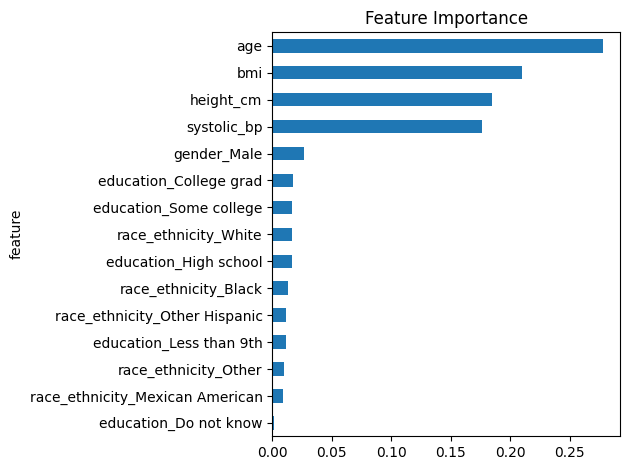

In [17]:
#Identifies which variables have the strongest influence on model predictions across the entire dataset. It ranks variables by their contribution to model predictions.
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

importance_df.plot(
    kind='barh',
    x='feature', y='importance',
    legend=False, title='Feature Importance'
)
plt.tight_layout()
plt.show()

# Auto ML

In [ ]:
#The code below will open an open source machine learning

In [22]:
pip install h2o

In [24]:
#This is basically where it's ranking the best model & let's us use it after.
import h2o
from h2o.automl import H2OAutoML

h2o.init()

# convert your existing splits
train = h2o.H2OFrame(X_train.assign(target=y_train))
test  = h2o.H2OFrame(X_test.assign(target=y_test))

x = X_train.columns.tolist()
y = 'target'

train['target'] = train['target'].asfactor()
test['target']  = test['target'].asfactor()

aml = H2OAutoML(max_models=10, seed=42)
aml.train(x=x, y=y, training_frame=train)

# leaderboard
aml.leaderboard.head()

# best model predictions
preds = aml.leader.predict(test)

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,3 mins 59 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 16 days
H2O_cluster_name:,H2O_from_python_unknownUser_rpb18u
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.156 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


In [26]:
#This prints out the best to worst in rank that was Auto ML
aml.leaderboard.head()

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_BestOfFamily_1_AutoML_2_20260429_03828,0.767293,0.350734,0.311718,0.315215,0.329683,0.108691
StackedEnsemble_AllModels_1_AutoML_2_20260429_03828,0.766339,0.351153,0.310419,0.32028,0.329881,0.108822
GBM_1_AutoML_2_20260429_03828,0.762645,0.35268,0.30575,0.311256,0.330413,0.109173
GLM_1_AutoML_2_20260429_03828,0.759653,0.354654,0.307912,0.310711,0.331129,0.109647
XGBoost_3_AutoML_2_20260429_03828,0.750242,0.364387,0.291629,0.319479,0.336064,0.112939
GBM_2_AutoML_2_20260429_03828,0.746515,0.361157,0.283594,0.326361,0.334452,0.111858
XGBoost_1_AutoML_2_20260429_03828,0.746264,0.368353,0.285342,0.325235,0.337847,0.114141
GBM_3_AutoML_2_20260429_03828,0.74545,0.362089,0.296462,0.321436,0.334017,0.111567
XRT_1_AutoML_2_20260429_03828,0.738048,0.372291,0.280878,0.310197,0.336078,0.112948
GBM_4_AutoML_2_20260429_03828,0.732616,0.368902,0.27834,0.330702,0.336916,0.113512
